## Hypothesis

Exploration should mainly occur during the early stage of learning.

Once the agent has experienced a sufficient number of state-action pairs, maintaining a high exploration rate becomes less beneficial.

Therefore, a sudden reduction of epsilon after sufficient exploration may achieve performance comparable to gradual epsilon decay.

This hypothesis will be tested experimentally.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
class CarEnv:
    def __init__(self, reward_type="A"):
        self.m = 1000.0
        self.dt = 0.1
        self.force_scale = 1000.0
        self.target = 10.0
        self.reward_type = reward_type

        self.x = 0.0
        self.v = 0.0
        self.previous_distance = 0.0
        self.current_distance = 0.0
        self.error = self.target - self.x

    def reset(self):
        self.x = 0.0
        self.v = 0.0
        self.previous_distance = abs(self.target - self.x)
        self.current_distance = abs(self.target - self.x)
        self.error = self.target - self.x
        return np.array([self.x, self.v])

    def step(self, action):
        self.previous_distance = abs(self.target - self.x)

        F = action * self.force_scale
        a = F / self.m

        self.v = self.v + a * self.dt
        self.x = self.x + self.v * self.dt
        self.error = self.target - self.x
        self.current_distance = abs(self.target - self.x)

        next_state = np.array([self.x, self.v])
        done = self.x >= self.target

        reward = self.calculate_reward(
            self.previous_distance,
            self.current_distance,
            done
        )

        return next_state, reward, done

    def calculate_reward(self, prev_distance, new_distance, done):
        if self.reward_type == "A":
            reward = -new_distance

        elif self.reward_type == "B":
            if new_distance < prev_distance:
                reward = 1
            else:
                reward = -1

        elif self.reward_type == "C":
            if done:
                reward = 100
            else:
                reward = -1

        elif self.reward_type == "D":
            reward = -new_distance

            if new_distance < prev_distance:
                reward += 1
            elif new_distance > prev_distance:
                reward -= 1

            if done:
                reward += 100

        else:
            raise ValueError("reward_type must be one of: A, B, C, D")

        return reward

In [3]:
actions = [-1, 0, 1]

def discretize_state(state):
    x_bin = int(state[0])
    v_bin = int(state[1])
    return (x_bin, v_bin)

def get_q_values(Q, state):
    if state not in Q:
        Q[state] = [0.0, 0.0, 0.0]
    return Q[state]

def select_action(Q, state, epsilon):
    if random.random() < epsilon:
        action = np.random.choice(actions)
        return action
    else:
        q_values = get_q_values(Q, state)
        best_index = q_values.index(max(q_values))
        action = actions[best_index]
        return action

def update_q(Q, state, action, reward, next_state, alpha, gamma):
    q_values = get_q_values(Q, state)
    next_q_values = get_q_values(Q, next_state)

    action_idx = actions.index(action)

    q_values[action_idx] += alpha * (
        reward
        + gamma * max(next_q_values)
        - q_values[action_idx]
    )

In [4]:
num_episodes = 100
max_steps = 300

alpha = 0.1
gamma = 0.95
epsilon = 0.1

In [5]:
def get_epsilon(episode, strategy):
    if strategy == "constant_01":
        epsilon = 0.1
        return epsilon     
    elif strategy == "constant_1":
        epsilon = 1
        return epsilon
    elif strategy == "sudden_drop":
        epsilon = 1
        if episode / num_episodes > 0.5:
            epsilon = 0.1
        return epsilon
    elif strategy == "decay":
        epsilon_start = 1
        epsilon_min = 0.1
        decay_rate = 0.995
        epsilon = epsilon_start * (decay_rate ** episode)
        if epsilon < epsilon_min:
            epsilon = epsilon_min
        return epsilon

In [6]:
def train_q_learning(reward_type, strategy):
    env = CarEnv(reward_type)
    Q = {}

    episode_rewards = []
    success_log = []
    epsilon_log = []

    for episode in range(num_episodes):
        state = env.reset()
        total_reward = 0
        done = False

        epsilon = get_epsilon(episode, strategy)
        epsilon_log.append(epsilon)

        for step in range(max_steps):
            discrete_state = discretize_state(state)

            action = select_action(Q, discrete_state, epsilon)

            next_state, reward, done = env.step(action)

            discrete_next_state = discretize_state(next_state)

            update_q(
                Q,
                discrete_state,
                action,
                reward,
                discrete_next_state,
                alpha,
                gamma
            )

            state = next_state
            total_reward += reward

            if done:
                break

        episode_rewards.append(total_reward)
        success_log.append(done)

    return Q, episode_rewards, success_log, epsilon_log

In [7]:
def evaluate_policy(Q, reward_type):
    env = CarEnv(reward_type)
    state = env.reset()

    times = []
    positions = []
    velocities = []
    actions_log = []
    rewards = []

    done = False

    for step in range(max_steps):
        discrete_state = discretize_state(state)

        # 평가에서는 탐험하지 않음
        action = select_action(Q, discrete_state, epsilon=0.0)

        next_state, reward, done = env.step(action)

        times.append(step * env.dt)
        positions.append(state[0])
        velocities.append(state[1])
        actions_log.append(action)
        rewards.append(reward)

        state = next_state

        if done:
            break

    trajectory = {
        "times": times,
        "positions": positions,
        "velocities": velocities,
        "actions": actions_log,
        "rewards": rewards,
        "done": done
    }

    return trajectory

In [8]:
reward_type = "B"
strategies = ["constant_01", "constant_1", "sudden_drop", "decay"]

results = {}

for strategy in strategies:
    Q, episode_rewards, success_log, epsilon_log = train_q_learning(
        reward_type=reward_type,
        strategy=strategy
    )

    trajectory = evaluate_policy(Q, reward_type)

    results[strategy] = {
        "Q": Q,
        "episode_rewards": episode_rewards,
        "success_log": success_log,
        "epsilon_log": epsilon_log,
        "trajectory": trajectory
    }

    success_rate = sum(success_log) / len(success_log)

    print(
        f"Strategy {strategy} done | "
        f"success rate: {success_rate:.2f} | "
        f"Q states: {len(Q)}"
    )

Strategy constant_01 done | success rate: 0.95 | Q states: 22
Strategy constant_1 done | success rate: 0.28 | Q states: 181
Strategy sudden_drop done | success rate: 0.62 | Q states: 130
Strategy decay done | success rate: 0.76 | Q states: 105


In [9]:
def moving_average(data, window=50):
    data = np.array(data, dtype=float)
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window) / window, mode="valid")
#mode "valid" is to convolve when it is fully overlapped. Else it will return array [0].

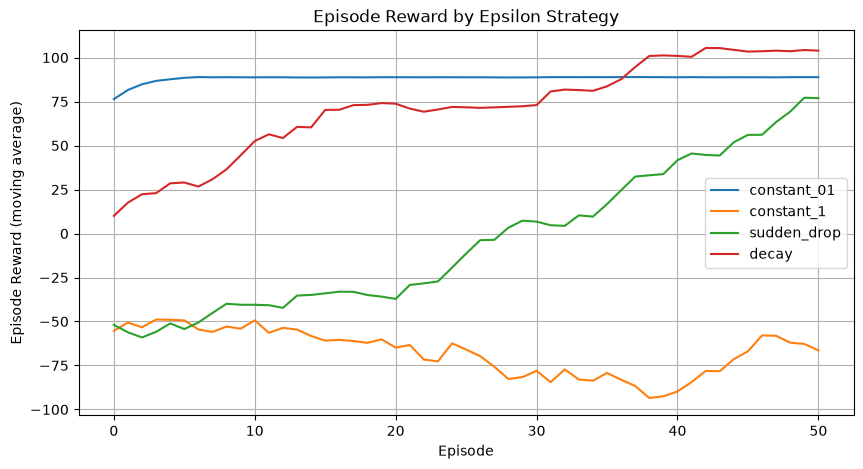

In [17]:
plt.figure(figsize=(10, 5))

for strategy in strategies:
    rewards = results[strategy]["episode_rewards"]
    smoothed_rewards = moving_average(rewards, window=50)
    plt.plot(smoothed_rewards, label=strategy)

plt.xlabel("Episode")
plt.ylabel("Episode Reward (moving average)")
plt.title("Episode Reward by Epsilon Strategy")
plt.legend()
plt.grid(True)
plt.show()

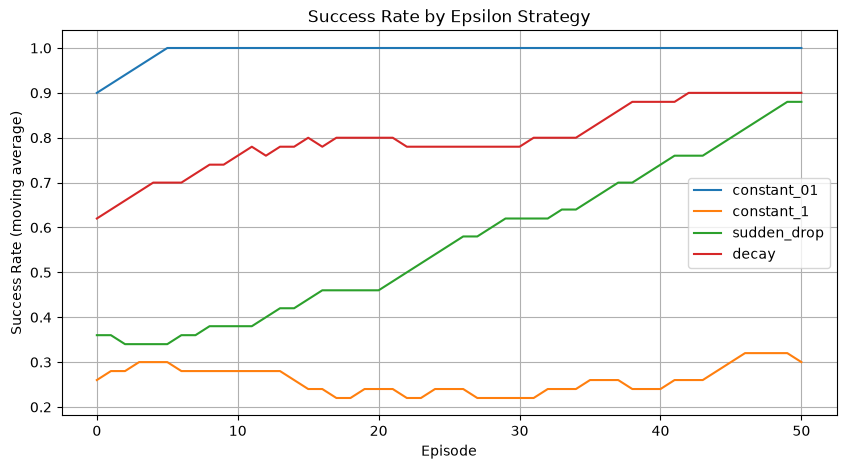

In [11]:
plt.figure(figsize=(10, 5))

for strategy in strategies:
    success_log = results[strategy]["success_log"]
    success_rate = moving_average(success_log, window=50)
    plt.plot(success_rate, label=strategy)

plt.xlabel("Episode")
plt.ylabel("Success Rate (moving average)")
plt.title("Success Rate by Epsilon Strategy")
plt.legend()
plt.grid(True)
plt.show()

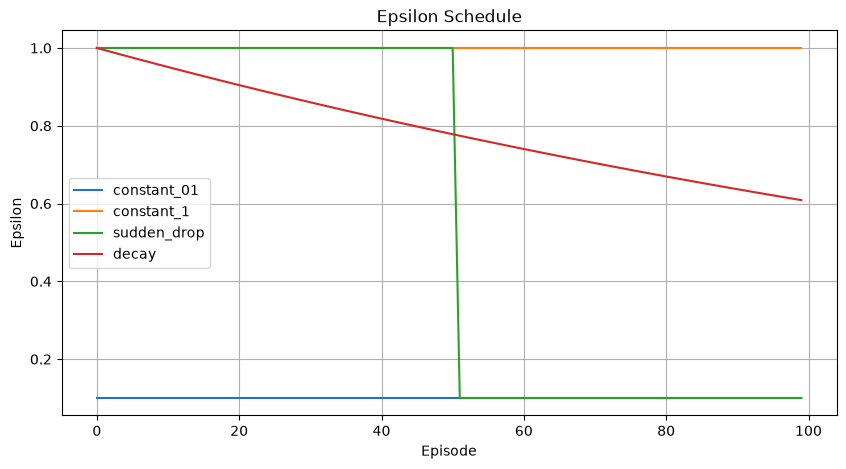

In [12]:
plt.figure(figsize=(10, 5))

for strategy in strategies:
    epsilon_log = results[strategy]["epsilon_log"]
    plt.plot(epsilon_log, label=strategy)

plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Epsilon Schedule")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
for strategy in strategies:
    rewards = results[strategy]["episode_rewards"]
    success_log = results[strategy]["success_log"]
    trajectory = results[strategy]["trajectory"]

    avg_reward_last_100 = np.mean(rewards[-100:])
    success_rate = np.mean(success_log)
    eval_steps = len(trajectory["actions"])
    eval_done = trajectory["done"]

    print(f"{strategy}")
    print(f"  Avg reward last 100: {avg_reward_last_100:.2f}")
    print(f"  Training success rate: {success_rate:.2f}")
    print(f"  Eval success: {eval_done}")
    print(f"  Eval steps: {eval_steps}")
    print()

constant_01
  Avg reward last 100: 82.62
  Training success rate: 0.95
  Eval success: True
  Eval steps: 89

constant_1
  Avg reward last 100: -60.87
  Training success rate: 0.28
  Eval success: False
  Eval steps: 300

sudden_drop
  Avg reward last 100: 12.53
  Training success rate: 0.62
  Eval success: True
  Eval steps: 98

decay
  Avg reward last 100: 56.98
  Training success rate: 0.76
  Eval success: True
  Eval steps: 96

